# Exercise 005

<a href="https://colab.research.google.com/github/FAIRChemistry/PythonProgramming2025/blob/master/exercises/Exercise005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Please execute this cell to download the necessary data
!wget https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv

--2026-05-23 07:47:49--  https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv [following]
--2026-05-23 07:47:50--  https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3663624 (3.5M) [text/plain]
Saving to: ‘gc_len_data.csv’

gc_len_data.csv     100%[===================>]   3.49M  --.-KB/s    in 0.02s   

2026-05-23 07:47:50 (172 MB/s) - ‘gc_len_data.csv’ saved [3663624/3663624]

In [2]:
# Please execute this cell to install the necessary packages
%pip install seaborn matplotlib pandas numpy scikit-learn

## Data Clustering #1

Read in the data `gc_len_data.csv` using Pandas, perform KMeans clustering, visualize the result with a suitable plot, and compare it to the original data.

What do you notice? Was the data clustered correctly?

**Tips**

> * To visualize the data, you may want to use a dimensionality reduction method, such as the Principal Component Analysis, to confirm the clustering result visually. Check the Sciki-Learn's documentation for guidance on implementing your own method. If you're having trouble, you can use the implementation from the previous exercise, available [here](https://jr-1991.github.io/PythonProgrammingBio24/solutions/Exercise004/).
> * This dataset consists of various data types, but the clustering method only works with numeric data. Use the `filter` method to narrow down the dataset to columns that are compatible with the algorithm.

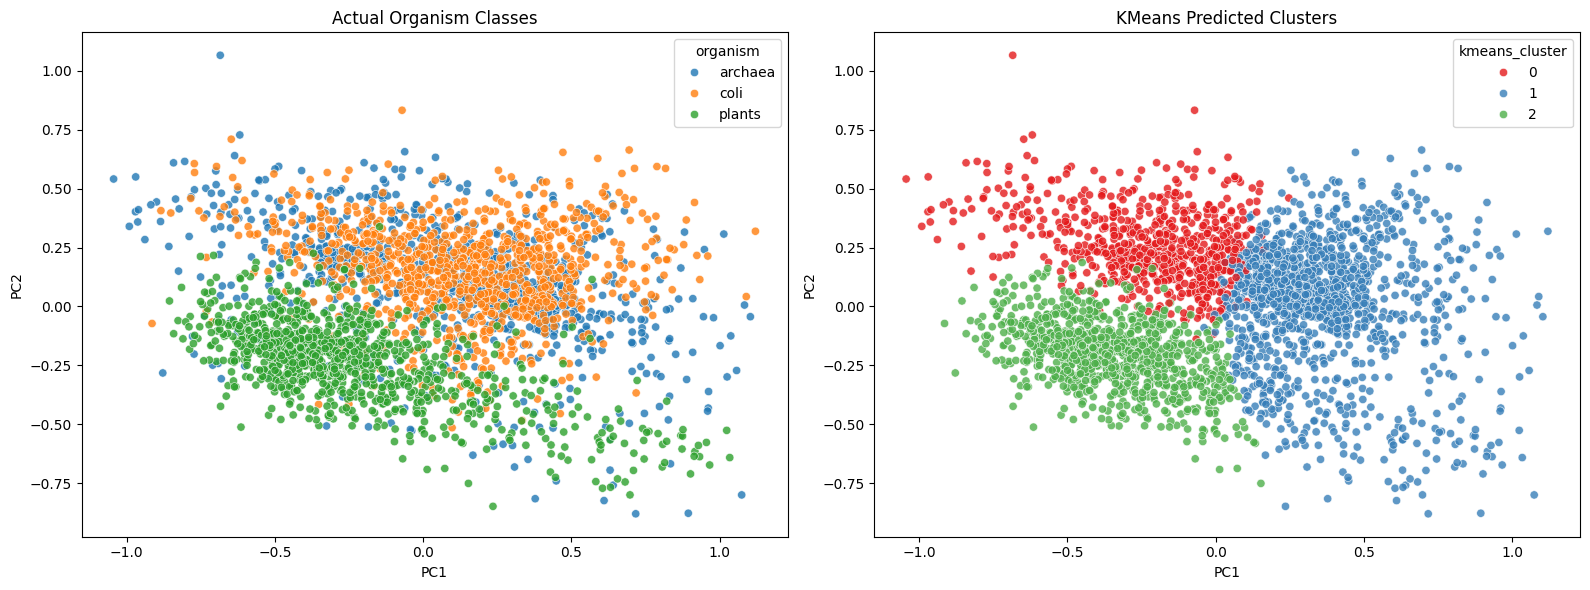

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# 1. Read dataset
df = pd.read_csv("gc_len_data.csv")

# 2. Extract and scale numeric data (excluding 'organism')
numeric_data = df.select_dtypes(include="number")
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(numeric_data)

# 3. Perform KMeans Clustering (k=3 because we know there are 3 groups)
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans_model.fit_predict(scaled_X)

# 4. Generate 2D PCA Coordinates for visualization
pcs = PCA(n_components=2).fit_transform(scaled_X)
df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]

# 5. Plot Comparison: Actual Organisms vs KMeans Clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x="PC1", y="PC2", hue="organism", data=df, alpha=0.8, ax=axes[0])
axes[0].set_title("Actual Organism Classes")

# Map clusters to integers cleanly for visual evaluation
sns.scatterplot(x="PC1", y="PC2", hue="kmeans_cluster", palette="Set1", data=df, alpha=0.8, ax=axes[1])
axes[1].set_title("KMeans Predicted Clusters")

plt.tight_layout()
plt.show()

## Data Clustering #2

KMeans is a powerful algorithm for detecting clusters, but it requires prior knowledge and assumes linear decision boundaries. Determining the appropriate number of 'classes' in your dataset can be challenging. Review SciKit-Learn's [documentation](https://scikit-learn.org/stable/modules/clustering.html) on clustering algorithms and try out at least one or two of them to repeat the previous task.

How do they perform? Which one do you prefer and why?

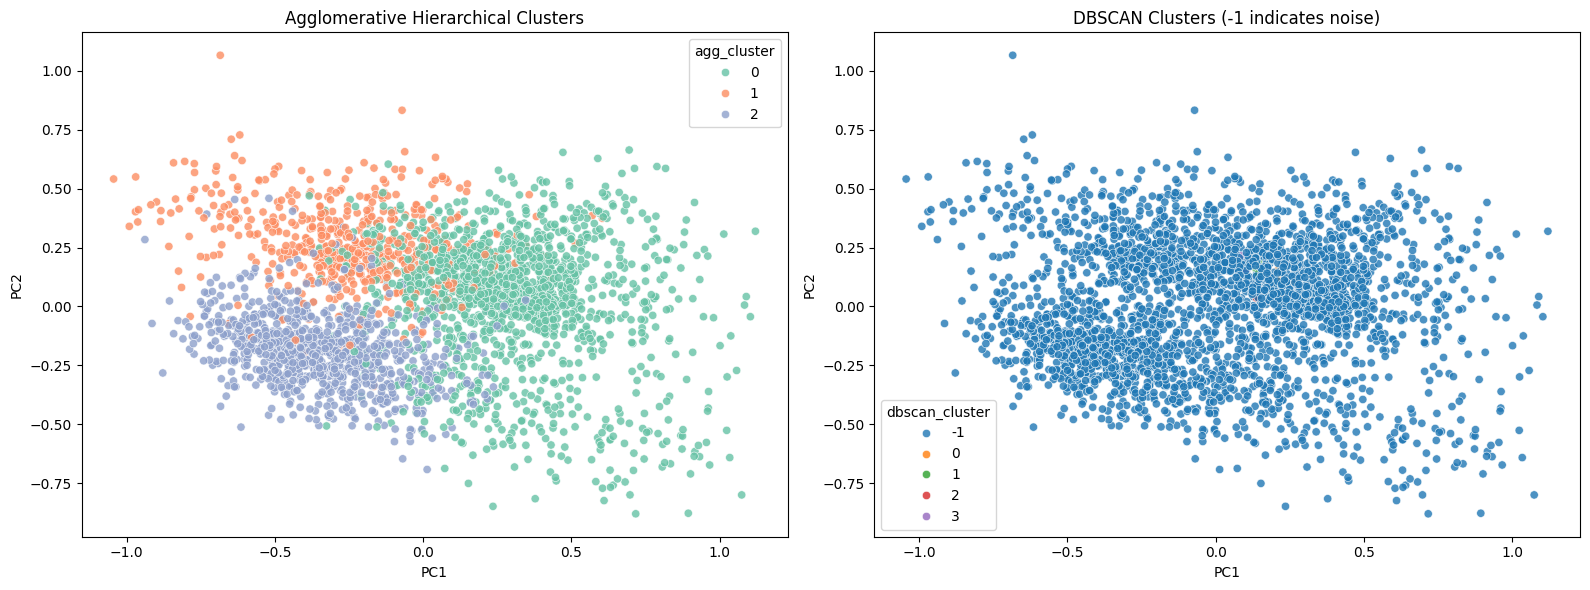

In [4]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering

# 1. Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
df["agg_cluster"] = agg.fit_predict(scaled_X)

# 2. Apply DBSCAN (adjusting eps and min_samples to match scaled density)
dbscan = DBSCAN(eps=0.25, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(scaled_X)

# 3. Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x="PC1", y="PC2", hue="agg_cluster", palette="Set2", data=df, alpha=0.8, ax=axes[0])
axes[0].set_title("Agglomerative Hierarchical Clusters")

sns.scatterplot(x="PC1", y="PC2", hue="dbscan_cluster", palette="tab10", data=df, alpha=0.8, ax=axes[1])
axes[1].set_title("DBSCAN Clusters (-1 indicates noise)")

plt.tight_layout()
plt.show()

## Implementing KMeans

Your task is to implement the kmeans function using the provided helper functions. The kmeans function should take the input data points, the number of clusters, the maximum number of iterations, and the tolerance for convergence as arguments. It should return the final centroids and the labels assigned to each data point. The implementation is outlined as follows:

1. Initialize centroids

    * Use the `initialize_centroids` function to randomly select initial centroids from the data points.

2. Iterate until convergence or maximum iterations:

    * In each iteration
        * Assign labels to each data point based on the nearest centroid using the assign_labels function.
        * Compute new centroids as the mean of all points assigned to each cluster using the compute_centroids function.
        * Check for convergence using the has_converged function.
        * If converged, break the loop.

3. Return results:
    * Return the final centroids and the labels assigned to each data point.

### Helper functions

Execute the following cell to make use of the helper functions.

In [5]:
import numpy as np


def initialize_centroids(X, n_clusters):
    """
    Randomly initialize centroids from the data points.

    Args:
        X (numpy.ndarray): The input data points.
        n_clusters (int): The number of clusters.

    Returns:
        numpy.ndarray: The initialized centroids.
    """
    np.random.seed(42)
    random_indices = np.random.permutation(X.shape[0])
    centroids = X[random_indices[:n_clusters]]
    return centroids


def assign_labels(X, centroids):
    """
    Assign labels to each data point based on the nearest centroid.

    Args:
        X (numpy.ndarray): The input data points.
        centroids (numpy.ndarray): The current centroids.

    Returns:
        numpy.ndarray: The labels assigned to each data point.
    """
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels


def compute_centroids(X, labels, n_clusters):
    """
    Compute new centroids as the mean of all points assigned to each cluster.

    Args:
        X (numpy.ndarray): The input data points.
        labels (numpy.ndarray): The labels assigned to each data point.
        n_clusters (int): The number of clusters.

    Returns:
        numpy.ndarray: The new centroids.
    """
    centroids = np.zeros((n_clusters, X.shape[1]))
    for k in range(n_clusters):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            centroids[k] = np.mean(cluster_points, axis=0)
    return centroids


def has_converged(old_centroids, new_centroids, tol):
    """
    Check if the centroids have converged.

    Args:
        old_centroids (numpy.ndarray): The old centroids.
        new_centroids (numpy.ndarray): The new centroids.
        tol (float): The tolerance for convergence.

    Returns:
        bool: True if the centroids have converged, False otherwise.
    """
    return np.all(np.abs(old_centroids - new_centroids) < tol)

In [10]:
def kmeans(df, n_clusters=3, max_iter=300, tol=1e-4):
    """
    Apply the KMeans clustering algorithm.

    Args:
        df (pd.DataFrame): The input dataframe containing categorical and numeric variables.
        n_clusters (int): The number of clusters.
        max_iter (int): The maximum number of iterations.
        tol (float): The tolerance for convergence.

    Returns:
        tuple: The final centroids and the labels assigned to each data point.
    """
    # 1. Convert the DataFrame to a scaled NumPy Array
    X_raw = df.select_dtypes(include="number").values

    # We apply normalization internally to ensure mathematical distance works correctly
    X = (X_raw - X_raw.min(axis=0)) / (X_raw.max(axis=0) - X_raw.min(axis=0))

    # Step 1: Initialize centroids randomly using the helper function
    centroids = initialize_centroids(X, n_clusters)

    # Track labels container initialization
    labels = np.zeros(X.shape[0])

    # Step 2: Iterate until convergence or reaching maximum iterations limit
    for iteration in range(max_iter):
        old_centroids = centroids.copy()

        # 2a. Assign each data point to its closest centroid
        labels = assign_labels(X, centroids)

        # 2b. Recompute center point means based on new cluster populations
        centroids = compute_centroids(X, labels, n_clusters)

        # 2c. Check if centroid positions stabilized within target tolerance limit
        if has_converged(old_centroids, centroids, tol):
            print(f"KMeans converged successfully at iteration index: {iteration}")
            break

    # Step 3: Return final calculated results
    return centroids, labels

# Test your scratch function implementation
final_centroids, custom_labels = kmeans(df, n_clusters=3)

# View our cluster counts to verify allocations look balanced
print("Data sample cluster distribution counts:", np.bincount(custom_labels))

KMeans converged successfully at iteration index: 3
Data sample cluster distribution counts: [ 691  909 1400]
